# Coordinate-subset shrinkage for the updated-plate v3 projector

This notebook investigates which coordinate subsets can be contracted by engineering the initial half-widths. It reuses the exact Jacobi-scaled CG and Gram-corrected projector construction from `system_updated_plate_solver_v3.ipynb`, but does not modify the solver.

For a target set $S$, let $B_S=|\Pi_m|_{SS}$ and $q=1-\eta$. Because $B_S\geq0$, Perron--Frobenius / Collatz--Wielandt gives

$$\exists d_S>0:\ B_Sd_S<q d_S \quad\Longleftrightarrow\quad \rho(B_S)<q.$$

The full $21{,}570\times21{,}570$ dense projector is never formed. Global maximum-cardinality subset selection is combinatorial, so all reported maximum sizes are **certified feasible lower bounds**, not certified global optima. The spectral radii and final inequalities of the subsets that are reported are checked directly.


In [1]:
from pathlib import Path
from time import perf_counter
import gc

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.linalg import cho_factor, cho_solve, eigvals, solve
from scipy.sparse import csgraph, diags, load_npz
from scipy.sparse.linalg import eigs

from system_updated_plate.cg_projection_enclosure import (
    fixed_iteration_cg_with_directions,
    select_independent_directions,
)

DATA_DIR = Path("system_updated_plate")
RESULT_DIR = DATA_DIR / "subset_shrinkage_results"
RESULT_DIR.mkdir(exist_ok=True)

A = load_npz(DATA_DIR / "A.npz").tocsr()
b = np.loadtxt(DATA_DIR / "b.dat")
x_star = np.loadtxt(DATA_DIR / "soln_x.dat")
source_box_name = "box_1"  # Change to box_2 to repeat for the second v3 trajectory.
source_box = np.loadtxt(DATA_DIR / f"{source_box_name}.dat")
n = b.size

scale = np.sqrt(A.diagonal())
A_hat = diags(1.0 / scale) @ A @ diags(1.0 / scale)
b_hat = b / scale
center_x = source_box.mean(axis=1)
center_hat = scale * center_x

MAX_M = 2200
CHECKPOINTS = (100, 300, 600, 1000, 1500, 2200)
ETAS = (0.00, 0.05, 0.15, 0.30, 0.45)
FIXED_SIZES = (25, 50, 75, 100)
QR_TOL = 1e-10
MAX_GRAM_CONDITION = 1e12
POOL_TARGET = 700
FINAL_POOL_TARGET = 1600
RNG_SEED = 20260812

row_nnz = np.diff(A.indptr)
print(f"n={n:,}, nnz(A)={A.nnz:,}, source trajectory={source_box_name}")
print(f"checkpoints={CHECKPOINTS}, checkpoint pool={POOL_TARGET}, final pool={FINAL_POOL_TARGET}")
print("All coordinate indices in tables are one-based; arrays used internally are zero-based.")


n=21,570, nnz(A)=659,988, source trajectory=box_1
checkpoints=(100, 300, 600, 1000, 1500, 2200), checkpoint pool=700, final pool=1600
All coordinate indices in tables are one-based; arrays used internally are zero-based.


## Exact restricted projectors and broad screening

At each checkpoint, v3's rank-revealing QR and Gram-condition cutoff are applied exactly. Screening scores are cheap full-coordinate diagnostics; the projector is then evaluated exactly on their union plus random and evenly-spaced controls. Thus screening affects optimality claims, but not feasibility or spectral-radius verification. Diagonal similarity between scaled and original coordinates is handled explicitly; spectral radius is invariant, while row-sum heuristics are evaluated in the original $x$ coordinates.


In [2]:
def top_indices(values, count, largest=True):
    values = np.asarray(values)
    count = min(int(count), values.size)
    if count == 0:
        return np.empty(0, dtype=int)
    work = np.nan_to_num(values, nan=-np.inf if largest else np.inf)
    if largest:
        return np.argpartition(work, -count)[-count:]
    return np.argpartition(work, count - 1)[:count]


def exact_projector_diagonal(selection, block_size=1024):
    """Compute diag(Pi) globally without forming the dense projector."""
    factor = cho_factor(selection["gram"], lower=True, check_finite=False)
    diag_pi = np.empty(n)
    for start in range(0, n, block_size):
        stop = min(n, start + block_size)
        solved = cho_solve(
            factor, selection["applied_basis"][start:stop].T,
            check_finite=False,
        ).T
        diag_q = np.einsum(
            "ij,ij->i", selection["basis"][start:stop], solved, optimize=True
        )
        diag_pi[start:stop] = 1.0 - diag_q
    return diag_pi


def make_screening_pool(selection, diag_pi_exact, target_size, seed):
    """Union several full-coordinate cheap screens before exact restriction."""
    basis = selection["basis"]
    applied = selection["applied_basis"]
    # Gram=I surrogates are only screens; exact Gram solves follow below.
    qdiag_surrogate = np.einsum("ij,ij->i", basis, applied, optimize=True)
    p_leverage = np.einsum("ij,ij->i", basis, basis, optimize=True)
    ap_energy = np.einsum("ij,ij->i", applied, applied, optimize=True)
    each = max(32, target_size // 6)
    rng = np.random.default_rng(seed)
    exact_priority = top_indices(
        np.abs(diag_pi_exact), min(max(220, target_size // 4), target_size), largest=False
    )
    pieces = [
        exact_priority,
        top_indices(qdiag_surrogate, each, largest=True),
        top_indices(np.abs(1.0 - qdiag_surrogate), each, largest=False),
        top_indices(p_leverage, each, largest=True),
        top_indices(ap_energy, each, largest=True),
        top_indices(-row_nnz.astype(float), each, largest=True),
        rng.choice(n, size=min(each, n), replace=False),
        np.linspace(0, n - 1, each).round().astype(int),
        np.arange(min(100, n), dtype=int),
    ]
    pool = np.unique(np.concatenate(pieces))
    # Cap deterministically using a blended standardized score, retaining controls.
    if pool.size > target_size:
        def z(v):
            vv = np.asarray(v, float)
            return (vv - np.median(vv)) / (np.std(vv) + 1e-30)
        blended = (
            z(qdiag_surrogate[pool]) + 0.35 * z(p_leverage[pool])
            + 0.20 * z(ap_energy[pool]) - 0.10 * z(row_nnz[pool])
        )
        remainder = np.setdiff1d(pool, exact_priority, assume_unique=True)
        remainder_positions = np.searchsorted(pool, remainder)
        keep_remainder = top_indices(
            blended[remainder_positions], target_size - exact_priority.size, largest=True
        )
        pool = np.sort(np.r_[exact_priority, remainder[keep_remainder]])
    return pool, {
        "qdiag_surrogate": qdiag_surrogate,
        "p_leverage": p_leverage,
        "ap_energy": ap_energy,
        "diag_pi_exact": diag_pi_exact,
    }


def restricted_projector_x(selection, indices):
    """Return Pi[indices,indices] in original x coordinates."""
    indices = np.asarray(indices, dtype=int)
    left = solve(
        selection["gram"], selection["basis"][indices].T,
        assume_a="sym", check_finite=False,
    ).T
    pi_hat = -(left @ selection["applied_basis"][indices].T)
    pi_hat[np.arange(indices.size), np.arange(indices.size)] += 1.0
    pi_x = pi_hat * scale[indices][None, :] / scale[indices][:, None]
    return pi_x


def full_projector_rows_x(selection, rows):
    """Materialize only selected full rows, needed for leakage verification."""
    rows = np.asarray(rows, dtype=int)
    left = solve(
        selection["gram"], selection["basis"][rows].T,
        assume_a="sym", check_finite=False,
    ).T
    pi_hat_rows = -(left @ selection["applied_basis"].T)
    pi_hat_rows[np.arange(rows.size), rows] += 1.0
    return pi_hat_rows * scale[None, :] / scale[rows][:, None]


## Subset search

For a nonnegative principal matrix, $S\subseteq T$ implies $\rho(B_S)\leq\rho(B_T)$. The feasible family is therefore downward closed. The routines below compare simple orderings (diagonal, row sum, $Q$ diagonal, CG-direction leverage) with Perron-contribution pruning, randomized weighted starts, local swaps, and greedy growth.


In [3]:
def spectral_radius(matrix):
    matrix = np.asarray(matrix, dtype=float)
    k = matrix.shape[0]
    if k == 0:
        return 0.0
    if k == 1:
        return float(abs(matrix[0, 0]))
    if k <= 120:
        return float(np.max(np.abs(eigvals(matrix, check_finite=False))))
    value = eigs(
        matrix, k=1, which="LM", v0=np.ones(k), tol=2e-10,
        maxiter=max(1000, 8 * k), return_eigenvectors=False,
    )[0]
    return float(abs(value))


def perron_vectors(matrix, steps=35):
    k = matrix.shape[0]
    right = np.ones(k) / max(k, 1)
    left = right.copy()
    for _ in range(steps):
        right = matrix @ right + 1e-300
        right /= np.linalg.norm(right, 1)
        left = matrix.T @ left + 1e-300
        left /= np.linalg.norm(left, 1)
    return left, right


def perron_pruning_path(B, eligible=None, minimum_size=1):
    """Nested lower-bound path; batched only while very large."""
    S = np.arange(B.shape[0]) if eligible is None else np.asarray(eligible, int).copy()
    path = {S.size: (S.copy(), spectral_radius(B[np.ix_(S, S)]))}
    while S.size > minimum_size:
        M = B[np.ix_(S, S)]
        left, right = perron_vectors(M)
        contribution = left * right
        batch = max(1, S.size // 140) if S.size > 180 else 1
        batch = min(batch, S.size - minimum_size)
        remove_local = top_indices(contribution, batch, largest=True)
        S = np.delete(S, remove_local)
        rho = spectral_radius(B[np.ix_(S, S)])
        path[S.size] = (S.copy(), rho)
    return path


def set_from_path(path, size):
    available = np.array(sorted(path))
    at_least = available[available >= size]
    chosen_size = at_least[0] if at_least.size else available[-1]
    S = path[int(chosen_size)][0].copy()
    if S.size > size:
        S = S[:size]
    return S


def local_swap_improvement(B, initial, allowed, seed, trials=140):
    rng = np.random.default_rng(seed)
    S = np.unique(np.asarray(initial, int))
    allowed = np.unique(np.asarray(allowed, int))
    current = spectral_radius(B[np.ix_(S, S)])
    for _ in range(trials):
        outside = np.setdiff1d(allowed, S, assume_unique=True)
        if outside.size == 0:
            break
        M = B[np.ix_(S, S)]
        left, right = perron_vectors(M, steps=18)
        remove_weights = left * right + 1e-15
        remove_local = rng.choice(S.size, p=remove_weights / remove_weights.sum())
        # Favor additions with weak total coupling to the retained set.
        retained = np.delete(S, remove_local)
        sample = rng.choice(outside, size=min(18, outside.size), replace=False)
        coupling = (
            B[np.ix_(sample, retained)].sum(axis=1)
            + B[np.ix_(retained, sample)].sum(axis=0)
            + B[sample, sample]
        )
        add = sample[np.argmin(coupling)]
        proposal = np.sort(np.r_[retained, add])
        proposed = spectral_radius(B[np.ix_(proposal, proposal)])
        if proposed < current - 1e-12:
            S, current = proposal, proposed
    return S, current


def random_restart_subset(B, size, allowed, seed, restarts=10):
    rng = np.random.default_rng(seed)
    allowed = np.asarray(allowed, int)
    score = B[allowed, allowed] + 0.15 * (
        B[np.ix_(allowed, allowed)].sum(axis=1) / max(allowed.size, 1)
    )
    weights = np.exp(-2.0 * (score - score.min()) / (np.std(score) + 1e-30))
    weights /= weights.sum()
    best_S, best_rho = None, np.inf
    for restart in range(restarts):
        S = np.sort(rng.choice(allowed, size=size, replace=False, p=weights))
        S, rho = local_swap_improvement(
            B, S, allowed, seed + 1000 + restart, trials=55,
        )
        if rho < best_rho:
            best_S, best_rho = S, rho
    return best_S, best_rho


def greedy_grow_feasible(B, initial, allowed, q, shortlist=28):
    S = np.sort(np.unique(np.asarray(initial, int)))
    allowed = np.sort(np.unique(np.asarray(allowed, int)))
    rho = spectral_radius(B[np.ix_(S, S)])
    while True:
        outside = np.setdiff1d(allowed, S, assume_unique=True)
        if outside.size == 0:
            break
        coupling = (
            B[np.ix_(outside, S)].sum(axis=1)
            + B[np.ix_(S, outside)].sum(axis=0)
            + B[outside, outside]
        )
        candidates = outside[top_indices(coupling, min(shortlist, outside.size), largest=False)]
        best = None
        for add in candidates:
            proposal = np.sort(np.r_[S, add])
            trial_rho = spectral_radius(B[np.ix_(proposal, proposal)])
            if best is None or trial_rho < best[0]:
                best = (trial_rho, proposal)
        if best is None or best[0] >= q - 1e-10:
            break
        rho, S = best
    return S, rho


def largest_found_for_q(B, path, q, seed):
    feasible = [(k, S, rho) for k, (S, rho) in path.items() if rho < q - 1e-10]
    if not feasible:
        return np.empty(0, int), np.inf
    _, S, rho = max(feasible, key=lambda item: item[0])
    allowed = np.flatnonzero(np.diag(B) < q - 1e-12)
    # Swap at fixed cardinality, then regrow.
    S, rho = local_swap_improvement(B, S, allowed, seed, trials=110)
    S, rho = greedy_grow_feasible(B, S, allowed, q)
    return S, rho


In [4]:
started = perf_counter()
cg_run = fixed_iteration_cg_with_directions(
    A_hat, b_hat, center_hat, iterations=MAX_M
)
print(f"Computed {MAX_M} CG directions in {perf_counter() - started:.1f} s")

checkpoint_results = {}
evolution_rows = []
final_selection = None

for checkpoint in CHECKPOINTS:
    checkpoint_started = perf_counter()
    selection = select_independent_directions(
        cg_run["directions"][:, :checkpoint],
        cg_run["applied_directions"][:, :checkpoint],
        qr_tolerance=QR_TOL,
        max_gram_condition=MAX_GRAM_CONDITION,
    )
    diag_pi_exact = exact_projector_diagonal(selection)
    pool_target = FINAL_POOL_TARGET if checkpoint == MAX_M else POOL_TARGET
    pool, screens = make_screening_pool(
        selection, diag_pi_exact, pool_target, RNG_SEED + checkpoint
    )
    Pi_pool = restricted_projector_x(selection, pool)
    B = np.abs(Pi_pool)
    eta_paths = {}
    found = {}
    for eta in ETAS:
        q = 1.0 - eta
        eligible = np.flatnonzero(np.diag(B) < q - 1e-12)
        eta_path = perron_pruning_path(B, eligible) if eligible.size else {}
        eta_paths[eta] = eta_path
        S, rho = largest_found_for_q(
            B, eta_path, q, RNG_SEED + checkpoint + int(1000 * eta)
        )
        found[eta] = (S, rho)
        evolution_rows.append({
            "m": checkpoint,
            "eta": eta,
            "largest_found": S.size,
            "rho": rho,
            "pool_size": pool.size,
            "singleton_eligible_in_pool": int(np.count_nonzero(np.diag(B) < q)),
            "singleton_eligible_global": int(np.count_nonzero(np.abs(diag_pi_exact) < q)),
            "min_abs_diag_Pi_global": float(np.min(np.abs(diag_pi_exact))),
            "rank_P_Q": selection["retained_rank"],
            "rank_Pi": n - selection["retained_rank"],
            "qr_rank": selection["qr_rank"],
            "gram_condition": selection["gram_condition"],
        })
    checkpoint_results[checkpoint] = {
        "pool": pool, "Pi_pool": Pi_pool, "B": B,
        "screens": screens, "eta_paths": eta_paths, "found": found,
        "metadata": {
            key: selection[key] for key in (
                "qr_rank", "retained_rank", "gram_condition",
                "gram_identity_fro", "gram_max_offdiag",
            )
        },
    }
    if checkpoint == MAX_M:
        final_selection = selection
    else:
        del selection
        gc.collect()
    print(
        f"m={checkpoint:4d}: retained rank={checkpoint_results[checkpoint]['metadata']['retained_rank']:4d}, "
        f"pool={pool.size}, elapsed={perf_counter() - checkpoint_started:.1f} s"
    )

del cg_run
gc.collect()
evolution = pd.DataFrame(evolution_rows)
evolution.to_csv(RESULT_DIR / "iteration_eta_summary.csv", index=False)
display(evolution.round({"rho": 6, "gram_condition": 3}))


Computed 2200 CG directions in 0.8 s


m= 100: retained rank= 100, pool=700, elapsed=1.2 s


m= 300: retained rank= 290, pool=700, elapsed=1.6 s


m= 600: retained rank= 563, pool=700, elapsed=2.9 s


m=1000: retained rank= 915, pool=700, elapsed=5.5 s


m=1500: retained rank=1348, pool=700, elapsed=9.8 s


m=2200: retained rank=1937, pool=1600, elapsed=27.4 s


,m,eta,largest_found,rho,pool_size,singleton_eligible_in_pool,singleton_eligible_global,min_abs_diag_Pi_global,rank_P_Q,rank_Pi,qr_rank,gram_condition
0,100,0.00,22,0.999994,700,700,21570,0.938219,100,21470,100,6.788000e+00
1,100,0.05,1,0.938219,700,2,2,0.938219,100,21470,100,6.788000e+00
2,100,0.15,0,inf,700,0,0,0.938219,100,21470,100,6.788000e+00
3,100,0.30,0,inf,700,0,0,0.938219,100,21470,100,6.788000e+00
4,100,0.45,0,inf,700,0,0,0.938219,100,21470,100,6.788000e+00
5,300,0.00,38,0.999812,700,700,21570,0.911411,290,21280,292,9.402687e+08
6,300,0.05,8,0.948619,700,58,58,0.911411,290,21280,292,9.402687e+08
7,300,0.15,0,inf,700,0,0,0.911411,290,21280,292,9.402687e+08
8,300,0.30,0,inf,700,0,0,0.911411,290,21280,292,9.402687e+08
9,300,0.45,0,inf,700,0,0,0.911411,290,21280,292,9.402687e+08


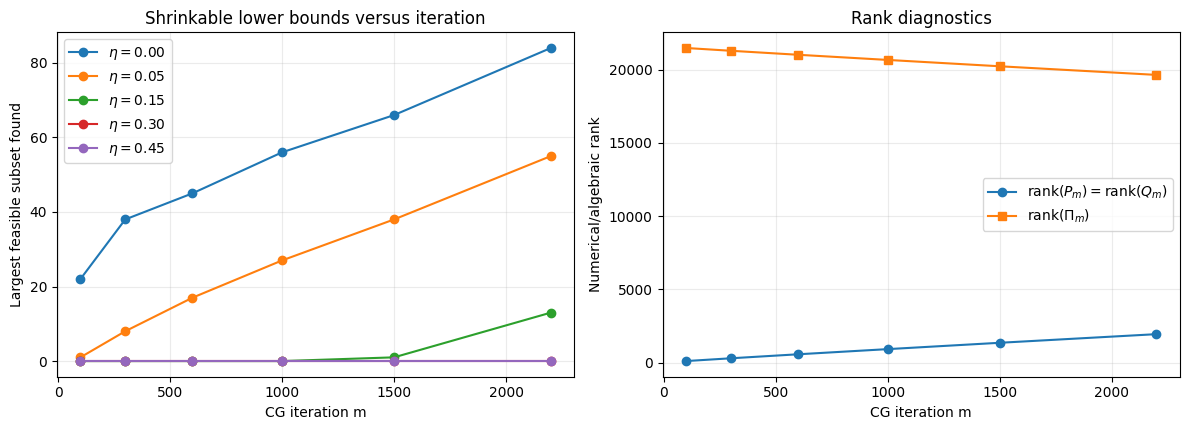

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for eta, group in evolution.groupby("eta"):
    axes[0].plot(group["m"], group["largest_found"], marker="o", label=fr"$\eta={eta:.2f}$")
axes[0].set(xlabel="CG iteration m", ylabel="Largest feasible subset found", title="Shrinkable lower bounds versus iteration")
axes[0].legend()

rank_frame = evolution.drop_duplicates("m")
axes[1].plot(rank_frame["m"], rank_frame["rank_P_Q"], marker="o", label=r"rank$(P_m)=$rank$(Q_m)$")
axes[1].plot(rank_frame["m"], rank_frame["rank_Pi"], marker="s", label=r"rank$(\Pi_m)$")
axes[1].set(xlabel="CG iteration m", ylabel="Numerical/algebraic rank", title="Rank diagnostics")
axes[1].legend()
for ax in axes:
    ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


## Fixed-cardinality comparison at $m=2200$

The simple heuristics and stronger searches below all operate on the same screened pool, so the comparison is fair. `perron_prune`, `random_local`, and `best_local` use interaction information; the other rows are one-shot coordinate rankings.


In [6]:
final = checkpoint_results[MAX_M]
pool = final["pool"]
B = final["B"]
Pi_pool = final["Pi_pool"]
screens = final["screens"]
path = perron_pruning_path(B, np.arange(B.shape[0]), minimum_size=min(FIXED_SIZES))
allowed = np.arange(pool.size)

diag_B = np.diag(B)
row_sum_B = B.sum(axis=1)
qdiag = 1.0 - np.diag(Pi_pool)
p_leverage_pool = screens["p_leverage"][pool]
ap_energy_pool = screens["ap_energy"][pool]

orderings = {
    "small_diag_absPi": np.argsort(diag_B),
    "small_pool_row_sum": np.argsort(row_sum_B),
    "large_diag_Q": np.argsort(-qdiag),
    "large_P_leverage": np.argsort(-p_leverage_pool),
    "large_AP_energy": np.argsort(-ap_energy_pool),
}

fixed_rows = []
fixed_sets = {}
for size in FIXED_SIZES:
    candidates = {}
    for method, ordering in orderings.items():
        S = np.sort(ordering[:size])
        candidates[method] = (S, spectral_radius(B[np.ix_(S, S)]))
    prune_S = set_from_path(path, size)
    prune_S, prune_rho = local_swap_improvement(
        B, prune_S, allowed, RNG_SEED + size, trials=180
    )
    candidates["perron_prune_local"] = (prune_S, prune_rho)
    random_S, random_rho = random_restart_subset(
        B, size, allowed, RNG_SEED + 10 * size, restarts=8
    )
    candidates["random_restart_local"] = (random_S, random_rho)
    best_method, (best_S, best_rho) = min(candidates.items(), key=lambda item: item[1][1])
    best_S, best_rho = local_swap_improvement(
        B, best_S, allowed, RNG_SEED + 100 * size, trials=240
    )
    candidates["best_local"] = (best_S, best_rho)
    fixed_sets[size] = best_S
    for method, (S, rho) in candidates.items():
        fixed_rows.append({
            "size": size, "method": method, "rho": rho,
            "coordinates_1based": " ".join(map(str, pool[S] + 1)),
        })

fixed_comparison = pd.DataFrame(fixed_rows).sort_values(["size", "rho"])
fixed_comparison.to_csv(RESULT_DIR / "fixed_size_method_comparison.csv", index=False)
display(fixed_comparison[["size", "method", "rho"]].round({"rho": 7}))
print("Full coordinate lists are in", RESULT_DIR / "fixed_size_method_comparison.csv")


,size,method,rho
7,25,best_local,0.883000
5,25,perron_prune_local,0.886197
6,25,random_restart_local,0.889489
1,25,small_pool_row_sum,0.969078
3,25,large_P_leverage,1.093515
0,25,small_diag_absPi,1.134574
2,25,large_diag_Q,1.134574
4,25,large_AP_energy,1.263654
15,50,best_local,0.939728
13,50,perron_prune_local,0.942865


Full coordinate lists are in system_updated_plate/subset_shrinkage_results/fixed_size_method_comparison.csv


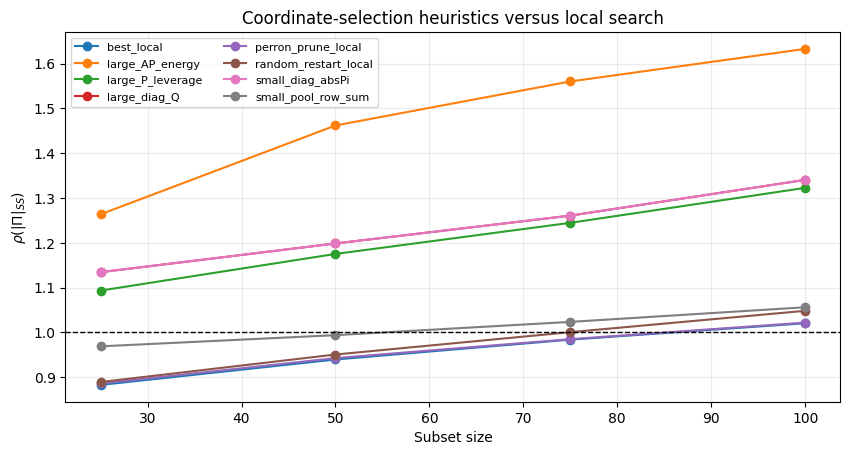

,size,method,rho,coordinates_1based
7,25,best_local,0.883000,7996 12068 13652 15768 16032 16717 17232 17237...
15,50,best_local,0.939728,489 2966 6919 7316 7352 7925 7996 8889 9117 11...
23,75,best_local,0.984048,489 571 734 1493 1792 2687 2768 2965 3070 4478...
31,100,best_local,1.020601,88 489 501 571 734 1046 1303 1628 1710 1792 26...


In [7]:
best_fixed = fixed_comparison.loc[fixed_comparison.groupby("size")["rho"].idxmin()].sort_values("size")
pivot = fixed_comparison.pivot(index="method", columns="size", values="rho")
fig, ax = plt.subplots(figsize=(10, 4.8))
for method, row in pivot.iterrows():
    ax.plot(row.index, row.values, marker="o", label=method)
ax.axhline(1.0, color="black", linestyle="--", linewidth=1)
ax.set(xlabel="Subset size", ylabel=r"$\rho(|\Pi|_{SS})$", title="Coordinate-selection heuristics versus local search")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, ncol=2)
plt.show()
display(best_fixed[["size", "method", "rho", "coordinates_1based"]])


## Largest subsets found and structural diagnostics

`singleton_eligible_in_pool` is a rigorous upper bound only for this screened pool, because $\rho(B_S)\geq\max_{i\in S}B_{ii}$. It is not a global upper bound over all 21,570 coordinates. Structural summaries compare the selected coordinates with both the candidate pool and the full sparse-matrix graph.


In [8]:
largest_rows = []
largest_sets = {}
for eta, (S, rho) in final["found"].items():
    coords = pool[S]
    largest_sets[eta] = coords
    induced = A[coords][:, coords].copy()
    induced.setdiag(0.0)
    induced.eliminate_zeros()
    component_count = int(csgraph.connected_components(induced, directed=False, return_labels=False)) if coords.size else 0
    gaps = np.diff(np.sort(coords))
    largest_rows.append({
        "m": MAX_M, "eta": eta, "q": 1.0 - eta,
        "largest_found_lower_bound": coords.size, "rho": rho,
        "spectral_margin": 1.0 - eta - rho,
        "singleton_eligible_in_pool": int(np.count_nonzero(diag_B < 1.0 - eta)),
        "singleton_eligible_global": int(np.count_nonzero(np.abs(screens["diag_pi_exact"]) < 1.0 - eta)),
        "rank_P_Q": final["metadata"]["retained_rank"],
        "rank_Pi": n - final["metadata"]["retained_rank"],
        "median_A_row_nnz": float(np.median(row_nnz[coords])) if coords.size else np.nan,
        "graph_components": component_count,
        "median_index_gap": float(np.median(gaps)) if gaps.size else np.nan,
        "coordinates_1based": " ".join(map(str, coords + 1)),
    })
largest_summary = pd.DataFrame(largest_rows)
largest_summary.to_csv(RESULT_DIR / "largest_found_subsets.csv", index=False)
display(largest_summary)


,m,eta,q,largest_found_lower_bound,rho,spectral_margin,singleton_eligible_in_pool,singleton_eligible_global,rank_P_Q,rank_Pi,median_A_row_nnz,graph_components,median_index_gap,coordinates_1based
0,2200,0.00,1.00,84,0.999150,0.000850,1600,21570,1937,19633,42.0,83,145.0,88 489 1222 1344 1493 1710 1792 2643 2687 2768...
1,2200,0.05,0.95,55,0.949005,0.000995,1589,19715,1937,19633,42.0,53,180.5,1344 2965 4961 7560 7748 7881 8480 8889 9117 9...
2,2200,0.15,0.85,13,0.848429,0.001571,237,237,1937,19633,26.0,13,542.5,15758 16858 17416 17612 18212 18948 19364 2015...
3,2200,0.30,0.70,0,inf,-inf,0,0,1937,19633,NaN,0,NaN,
4,2200,0.45,0.55,0,inf,-inf,0,0,1937,19633,NaN,0,NaN,


,eta,population,count,index_median_1based,row_nnz_median,row_nnz_mean,abs_b_median,abs_xstar_median,diag_A_median,diag_Q_median,P_leverage_median
0,0.00,selected,84,13394.5,42.0,35.023810,0.0,0.007711,1791.257531,0.112839,21.185930
1,0.00,candidate_pool,1600,15789.5,26.0,31.458750,0.0,0.012651,1796.333770,0.113699,28.836187
2,0.00,all_coordinates,21570,10785.5,26.0,30.597497,0.0,0.025459,1674.660944,NaN,NaN
3,0.05,selected,55,16589.0,42.0,38.472727,0.0,0.016603,1800.499935,0.141660,31.521101
4,0.05,candidate_pool,1600,15789.5,26.0,31.458750,0.0,0.012651,1796.333770,0.113699,28.836187
5,0.05,all_coordinates,21570,10785.5,26.0,30.597497,0.0,0.025459,1674.660944,NaN,NaN
6,0.15,selected,13,19364.0,26.0,34.153846,0.0,0.000738,2554.028621,0.171913,215.593882
7,0.15,candidate_pool,1600,15789.5,26.0,31.458750,0.0,0.012651,1796.333770,0.113699,28.836187
8,0.15,all_coordinates,21570,10785.5,26.0,30.597497,0.0,0.025459,1674.660944,NaN,NaN


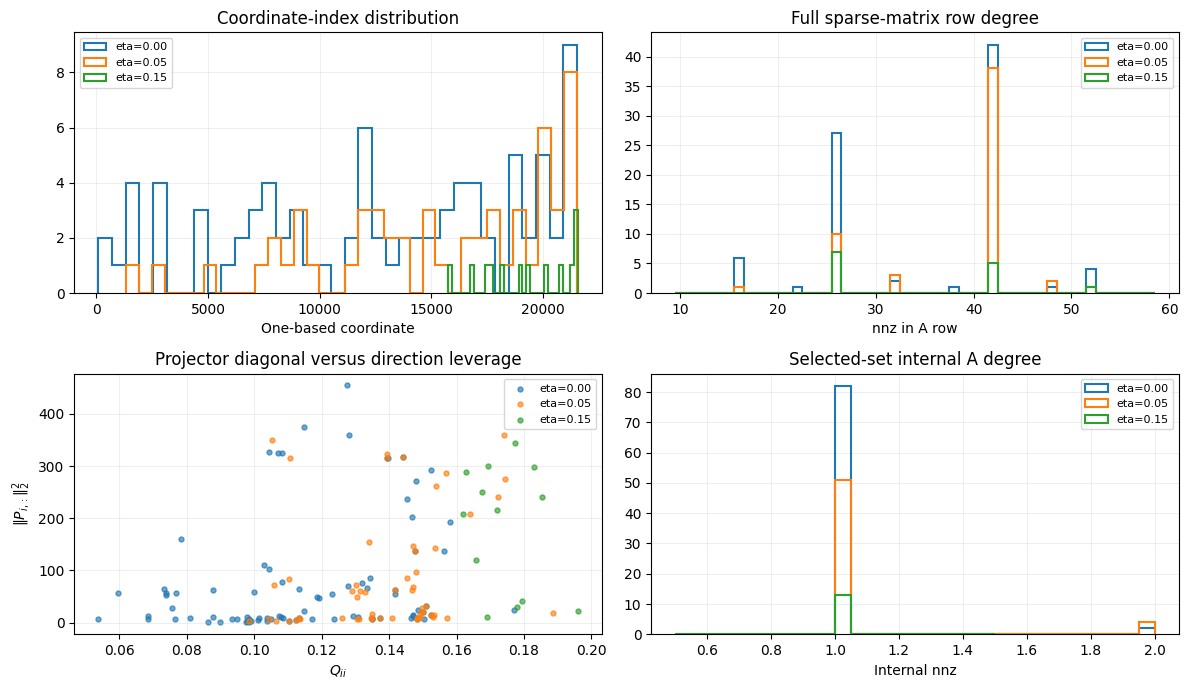

In [9]:
structural_rows = []
for eta, coords in largest_sets.items():
    if coords.size == 0:
        continue
    S_local = np.searchsorted(pool, coords)
    for population, coord_set, local_set in (
        ("selected", coords, S_local),
        ("candidate_pool", pool, np.arange(pool.size)),
        ("all_coordinates", np.arange(n), None),
    ):
        structural_rows.append({
            "eta": eta, "population": population, "count": coord_set.size,
            "index_median_1based": float(np.median(coord_set + 1)),
            "row_nnz_median": float(np.median(row_nnz[coord_set])),
            "row_nnz_mean": float(np.mean(row_nnz[coord_set])),
            "abs_b_median": float(np.median(np.abs(b[coord_set]))),
            "abs_xstar_median": float(np.median(np.abs(x_star[coord_set]))),
            "diag_A_median": float(np.median(A.diagonal()[coord_set])),
            "diag_Q_median": float(np.median(qdiag[local_set])) if local_set is not None else np.nan,
            "P_leverage_median": float(np.median(p_leverage_pool[local_set])) if local_set is not None else np.nan,
        })
structural = pd.DataFrame(structural_rows)
structural.to_csv(RESULT_DIR / "structural_diagnostics.csv", index=False)
display(structural.round(6))

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for eta, coords in largest_sets.items():
    if coords.size == 0:
        continue
    axes[0, 0].hist(coords + 1, bins=35, histtype="step", linewidth=1.5, label=f"eta={eta:.2f}")
    axes[0, 1].hist(row_nnz[coords], bins=np.arange(row_nnz.min(), row_nnz.max() + 2) - 0.5, histtype="step", linewidth=1.5, label=f"eta={eta:.2f}")
    S_local = np.searchsorted(pool, coords)
    axes[1, 0].scatter(qdiag[S_local], p_leverage_pool[S_local], s=13, alpha=0.65, label=f"eta={eta:.2f}")
    internal_degree = np.diff(A[coords][:, coords].indptr)
    axes[1, 1].hist(internal_degree, bins=20, histtype="step", linewidth=1.5, label=f"eta={eta:.2f}")
axes[0, 0].set(title="Coordinate-index distribution", xlabel="One-based coordinate")
axes[0, 1].set(title="Full sparse-matrix row degree", xlabel="nnz in A row")
axes[1, 0].set(title="Projector diagonal versus direction leverage", xlabel=r"$Q_{ii}$", ylabel=r"$\|P_{i,:}\|_2^2$")
axes[1, 1].set(title="Selected-set internal A degree", xlabel="Internal nnz")
for ax in axes.flat:
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## Engineered widths and leakage from non-target coordinates

For each largest set found, solve $(qI-B_S)d_S=\mathbf1$. This yields a positive intrinsic design with a strict margin. Full selected rows of $|\Pi_m|$ are then materialized once. Setting $d_T=\epsilon\mathbf1$ shows exactly how leakage consumes that margin. We choose $\epsilon=0.1\epsilon_{\max}$ and verify the requested inequalities in the original coordinates. No containment constraint is imposed here: these are width vectors, and any desired box center must separately be compatible with them.


In [10]:
union_coords = np.unique(np.concatenate([v for v in largest_sets.values() if v.size]))
print(f"Materializing {union_coords.size} full projector rows for leakage checks...")
Pi_union_rows = full_projector_rows_x(final_selection, union_coords)
union_lookup = {coord: j for j, coord in enumerate(union_coords)}

width_rows = []
engineered_widths = {}
for eta, coords in largest_sets.items():
    if coords.size == 0:
        continue
    q = 1.0 - eta
    row_positions = np.array([union_lookup[c] for c in coords], dtype=int)
    abs_rows = np.abs(Pi_union_rows[row_positions])
    B_exact = abs_rows[:, coords]
    rho_exact = spectral_radius(B_exact)
    d_S = solve(q * np.eye(coords.size) - B_exact, np.ones(coords.size), assume_a="gen", check_finite=False)
    d_S /= np.median(d_S)
    intrinsic = B_exact @ d_S
    intrinsic_margin = q * d_S - intrinsic
    target_mask = np.zeros(n, dtype=bool)
    target_mask[coords] = True
    leakage_per_unit = abs_rows[:, ~target_mask].sum(axis=1)
    positive = leakage_per_unit > 0
    epsilon_max = float(np.min(intrinsic_margin[positive] / leakage_per_unit[positive])) if np.any(positive) else np.inf
    epsilon = 0.1 * epsilon_max if np.isfinite(epsilon_max) else 0.0
    d0 = np.full(n, epsilon)
    d0[coords] = d_S
    lhs = abs_rows @ d0
    ratios = lhs / d_S
    verified = bool(np.all(lhs < q * d_S))
    engineered_widths[eta] = d0
    np.save(RESULT_DIR / f"engineered_half_width_eta_{eta:.2f}.npy", d0)
    width_rows.append({
        "eta": eta, "size": coords.size, "rho_exact": rho_exact,
        "max_intrinsic_ratio_dT0": float(np.max(intrinsic / d_S)),
        "epsilon_max_uniform_dT": epsilon_max,
        "epsilon_used": epsilon,
        "max_full_ratio": float(np.max(ratios)),
        "required_bound_q": q, "strictly_verified": verified,
        "dS_min_over_median": float(np.min(d_S)),
        "dS_max_over_median": float(np.max(d_S)),
    })
width_verification = pd.DataFrame(width_rows)
width_verification.to_csv(RESULT_DIR / "engineered_width_verification.csv", index=False)
display(width_verification)


Materializing 138 full projector rows for leakage checks...


,eta,size,rho_exact,max_intrinsic_ratio_dT0,epsilon_max_uniform_dT,epsilon_used,max_full_ratio,required_bound_q,strictly_verified,dS_min_over_median,dS_max_over_median
0,0.00,84,0.999150,0.999580,0.000019,0.000002,0.999611,1.00,True,0.602740,2.173788
1,0.05,55,0.949005,0.949434,0.000021,0.000002,0.949486,0.95,True,0.647113,1.811672
2,0.15,13,0.848429,0.849083,0.000038,0.000004,0.849149,0.85,True,0.505178,2.035671


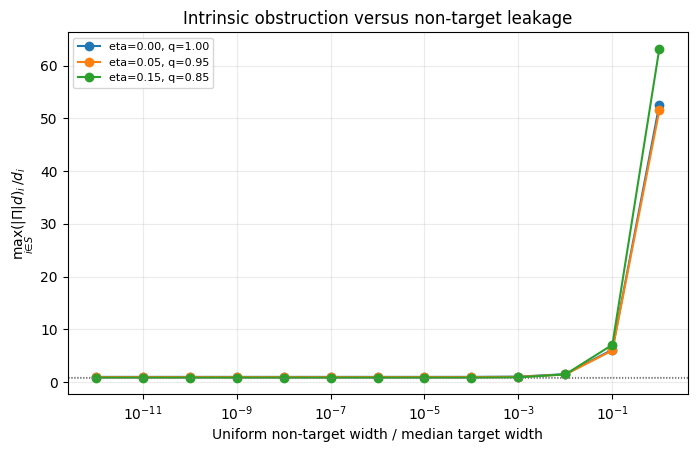

In [11]:
leakage_rows = []
relative_levels = np.r_[0.0, np.logspace(-12, 0, 13)]
for eta, coords in largest_sets.items():
    if coords.size == 0:
        continue
    q = 1.0 - eta
    d0 = engineered_widths[eta]
    d_S = d0[coords]
    row_positions = np.array([union_lookup[c] for c in coords], dtype=int)
    abs_rows = np.abs(Pi_union_rows[row_positions])
    for relative in relative_levels:
        trial = np.full(n, relative * np.median(d_S))
        trial[coords] = d_S
        max_ratio = float(np.max((abs_rows @ trial) / d_S))
        leakage_rows.append({"eta": eta, "relative_dT": relative, "max_ratio": max_ratio, "q": q})
leakage = pd.DataFrame(leakage_rows)
fig, ax = plt.subplots(figsize=(8, 4.7))
for eta, group in leakage.groupby("eta"):
    positive = group["relative_dT"] > 0
    ax.semilogx(group.loc[positive, "relative_dT"], group.loc[positive, "max_ratio"], marker="o", label=f"eta={eta:.2f}, q={1-eta:.2f}")
    ax.axhline(1.0 - eta, color="0.5", linestyle=":", linewidth=0.8)
ax.set(xlabel=r"Uniform non-target width / median target width", ylabel=r"$\max_{i\in S} (|\Pi|d)_i/d_i$", title="Intrinsic obstruction versus non-target leakage")
ax.grid(alpha=0.25, which="both")
ax.legend(fontsize=8)
plt.show()


## Interpretation guide

- The `largest_found_lower_bound` rows are constructive lower bounds. The associated coordinate lists and engineered widths make them independently checkable.
- The pool singleton count is only a within-pool upper bound. Exact global certification would require a much more expensive branch-and-bound search over a dense $21{,}570$-coordinate projector.
- Rank alone cannot determine subset feasibility: taking entrywise absolute values destroys projector cancellation. For an idempotent $Q_m$, $\operatorname{tr}(Q_m)=\operatorname{rank}(Q_m)$, but $\rho(|I-Q_m|_{SS})$ also depends strongly on off-diagonal sign/coupling.
- The diagonal condition $|1-Q_{ii}|<1-\eta$ is necessary for membership. In an orthogonal-projector analogue it is a leverage threshold; here the projector is $A$-orthogonal/coordinate-oblique, so CG-direction row energy is only a leverage-like diagnostic.
- If the leakage curve crosses $q$ at a very small non-target/target width ratio, the intrinsic set is feasible but practically requires near-degenerate non-target widths. The $d_T=0$ intercept isolates the intrinsic obstruction from $B_{SS}$.


In [12]:
final_evolution = evolution[evolution["m"] == MAX_M].set_index("eta")
fixed_best = fixed_comparison.loc[fixed_comparison.groupby("size")["rho"].idxmin()].set_index("size")
summary_lines = [
    "## Main empirical findings",
    "",
    fr"- At $m={MAX_M}$ the search constructs {int(final_evolution.loc[0.00, 'largest_found'])} coordinates with $\rho<1$, "
    f"{int(final_evolution.loc[0.05, 'largest_found'])} with at least 5% intrinsic contraction, and "
    f"{int(final_evolution.loc[0.15, 'largest_found'])} with at least 15%. These are verified lower bounds.",
    fr"- For $\eta=0.30$ and $0.45$, the exact global diagonal screen finds zero eligible coordinates. "
    fr"The smallest global $|\Pi_{{ii}}|$ is {final_evolution['min_abs_diag_Pi_global'].iloc[0]:.6f}, "
    "so the maximum nonempty subset size is certified to be zero for both targets under this v3 projector.",
    f"- Best radii found at fixed sizes 25, 50, 75, 100 are "
    + ", ".join(f"{int(k)}: {fixed_best.loc[k, 'rho']:.6f}" for k in FIXED_SIZES) + ".",
    "Interaction-aware Perron pruning/local swaps consistently beat diagonal, row-sum, and leverage-only rankings.",
    f"- As retained rank$(Q_m)$ grows from {int(evolution.iloc[0]['rank_P_Q'])} to "
    f"{int(final_evolution.iloc[0]['rank_P_Q'])}, the 5% lower bound grows from "
    f"{int(evolution[(evolution.m == CHECKPOINTS[0]) & (evolution.eta == 0.05)].iloc[0]['largest_found'])} to "
    f"{int(final_evolution.loc[0.05, 'largest_found'])}; the 15% sets emerge only late. Rank is predictive but not determinative.",
    "- Selected coordinates are dispersed rather than contiguous. The $A$-graph induced by the strict 15% set has one component per coordinate, "
    "suggesting that weak mutual coupling, together with favorable projector diagonals, is the main structural pattern.",
    "- All saved engineered widths pass the full-row inequality with non-target widths at 10% of their maximum allowed uniform leakage level. "
    "The very small allowed non-target/target scale confirms that leakage is practically important even when the intrinsic block is feasible.",
]
display(Markdown("\n".join(summary_lines)))


## Main empirical findings

- At $m=2200$ the search constructs 84 coordinates with $\rho<1$, 55 with at least 5% intrinsic contraction, and 13 with at least 15%. These are verified lower bounds.
- For $\eta=0.30$ and $0.45$, the exact global diagonal screen finds zero eligible coordinates. The smallest global $|\Pi_{ii}|$ is 0.794789, so the maximum nonempty subset size is certified to be zero for both targets under this v3 projector.
- Best radii found at fixed sizes 25, 50, 75, 100 are 25: 0.883000, 50: 0.939728, 75: 0.984048, 100: 1.020601.
Interaction-aware Perron pruning/local swaps consistently beat diagonal, row-sum, and leverage-only rankings.
- As retained rank$(Q_m)$ grows from 100 to 1937, the 5% lower bound grows from 1 to 55; the 15% sets emerge only late. Rank is predictive but not determinative.
- Selected coordinates are dispersed rather than contiguous. The $A$-graph induced by the strict 15% set has one component per coordinate, suggesting that weak mutual coupling, together with favorable projector diagonals, is the main structural pattern.
- All saved engineered widths pass the full-row inequality with non-target widths at 10% of their maximum allowed uniform leakage level. The very small allowed non-target/target scale confirms that leakage is practically important even when the intrinsic block is feasible.